<a href="https://colab.research.google.com/github/kinhalepuja31-cmd/-Superstore-Regional-Performance-Analytics/blob/main/Task19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_excel("/content/Global Superstore Data.xlsx",sheet_name="Orders")

In [4]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Product Name,Sub-Category,Category,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,24599,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,FUR-BO-4861,"Ikea Library with Doors, Mobile",Bookcases,Furniture,731.82,2,0.0,,39.66,Medium
1,29465,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,OFF-SU-2988,"Acme Scissors, Easy Grip",Supplies,Office Supplies,243.54,9,0.0,104.49,18.72,Medium
2,24598,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,TEC-MA-4211,"Epson Receipt Printer, White",Machines,Technology,346.32,3,0.0,13.77,14.10,Medium
3,24597,IN-2017-CA120551-42816,2017-03-22,2017-03-29,Standard Class,CA-120551,Cathy Armstrong,Home Office,NaN,Herat,...,FUR-FU-5726,"Rubbermaid Door Stop, Erganomic",Furnishings,Furniture,169.68,4,0.0,79.68,11.01,Medium
4,29464,ID-2015-BD116051-42248,2015-09-01,2015-09-04,Second Class,BD-116051,Brian Dahlen,Consumer,NaN,Herat,...,OFF-EN-3664,"Cameo Interoffice Envelope, with clear poly wi...",Envelopes,Office Supplies,203.88,4,0.0,24.36,5.72,Medium
5,28879,ID-2015-AJ107801-42113,2015-04-19,2015-04-22,First Class,AJ-107801,Anthony Jacobs,Corporate,NaN,Kabul,...,FUR-TA-3420,"Bevis Conference Table, Fully Assembled",Tables,Furniture,4626.15,5,0.0,647.55,835.57,High
6,27993,IN-2017-GM144551-42948,2017-08-01,2017-08-05,Standard Class,GM-144551,Gary Mitchum,Home Office,NaN,Kabul,...,FUR-BO-3626,"Bush Classic Bookcase, Pine",Bookcases,Furniture,2070.15,5,0.0,848.7,185.01,Medium
7,28967,IN-2017-VB217451-43080,2017-12-11,2017-12-15,Standard Class,VB-217451,Victoria Brennan,Corporate,NaN,Kabul,...,FUR-CH-4683,"Hon Rocking Chair, Red",Chairs,Furniture,914.34,7,0.0,356.58,106.41,High
8,29492,IN-2016-LO171701-42637,2016-09-24,2016-09-28,Standard Class,LO-171701,Lori Olson,Corporate,NaN,Kabul,...,TEC-PH-5814,"Samsung Audio Dock, VoIP",Phones,Technology,1168.44,7,0.0,443.94,92.34,Medium
9,28966,IN-2017-VB217451-43080,2017-12-11,2017-12-15,Standard Class,VB-217451,Victoria Brennan,Corporate,NaN,Kabul,...,TEC-PH-3129,"Apple Audio Dock, VoIP",Phones,Technology,500.94,3,0.0,115.2,79.59,High


Group the data by Product Name and calculate the total sales for each item.

In [5]:

product_sales = df.groupby('Product Name')['Sales'].sum().reset_index()


To fulfill the specific hint to check ties, use the .rank() function. The method='min' parameter ensures that products with identical sales get the same rank.

In [6]:

product_sales = product_sales.sort_values(by='Sales', ascending=False).reset_index(drop=True)       # 1. Sort descending by Sales


product_sales['Rank'] = product_sales['Sales'].rank(ascending=False, method='min').astype(int)      # 2. Assign ranks handling ties (method='min' gives tied items the lowest numerical rank)


top_10_products = product_sales[product_sales['Rank'] <= 10]                                        # 3. Filter for the Top 10 products


print("--- Top 10 Products by Sales ---")                                                            # Display the final Top-10 table deliverable
print(top_10_products)


--- Top 10 Products by Sales ---
                                        Product Name       Sales  Rank
0                       Apple Smart Phone, Full Size  86935.7786     1
1                       Cisco Smart Phone, Full Size  76441.5306     2
2                    Motorola Smart Phone, Full Size  73156.3030     3
3                       Nokia Smart Phone, Full Size  71904.5555     4
4              Canon imageCLASS 2200 Advanced Copier  61599.8240     5
5         Hon Executive Leather Armchair, Adjustable  58193.4841     6
6  Office Star Executive Leather Armchair, Adjust...  50661.6840     7
7  Harbour Creations Executive Leather Armchair, ...  50121.5160     8
8                      Samsung Smart Phone, Cordless  48653.4600     9
9                  Nokia Smart Phone, with Caller ID  47877.7857    10


Generate a clean horizontal bar chart to easily visualize the sales comparison.

/tmp/ipykernel_2251/3545046942.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


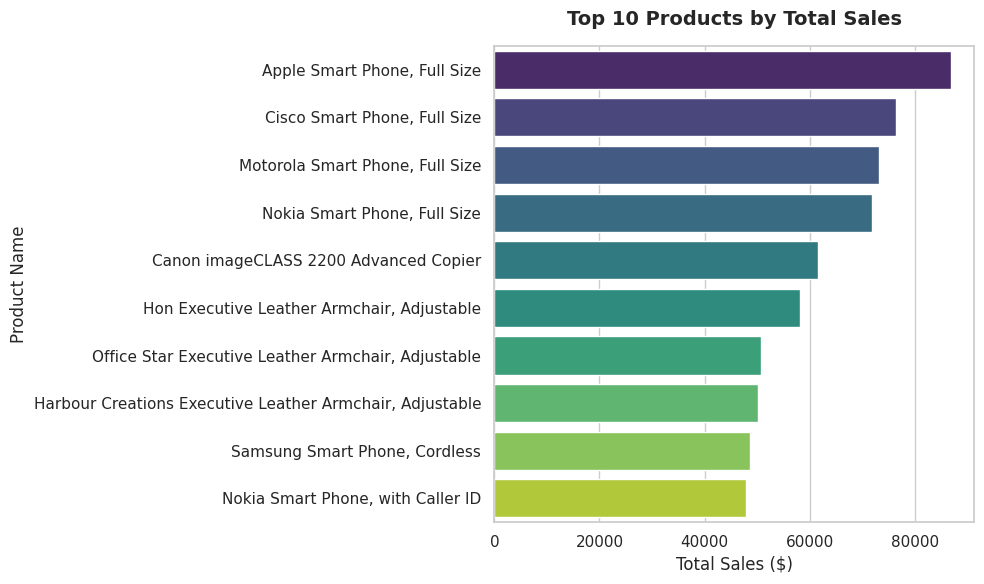

In [7]:

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")                         # Set the plot style and size

sns.barplot(
    x='Sales',
    y='Product Name',
    data=top_10_products,
    palette='viridis'
)                                                         # Create a horizontal bar plot

plt.title('Top 10 Products by Total Sales', fontsize=14, fontweight='bold', pad=15)                              # Customize chart labels and title
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)


plt.tight_layout()                                                       # Show the plot clearly in Colab
plt.show()


/tmp/ipykernel_2251/3668281612.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


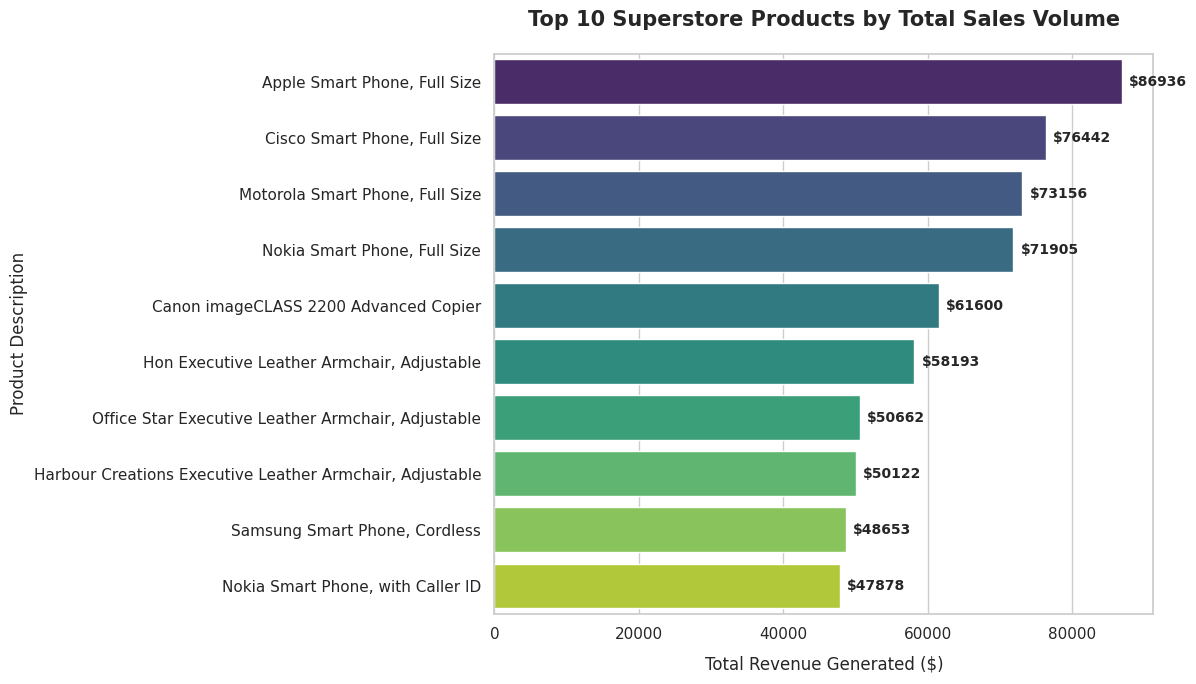

In [11]:
# 1. Load the data correctly (Make sure your uploaded file name matches 'Superstore.xlsx')
df_orders = pd.read_excel('/content/Global Superstore Data.xlsx', sheet_name='Orders')

# 2. Set clean visual styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 3. Group by Product Name and sum up the Sales (using the matching lowercase df_orders)
product_sales = df_orders.groupby('Product Name')['Sales'].sum().reset_index()

# 4. Sort values descending and assign competition ranks (method='min' handles ties)
product_sales = product_sales.sort_values(by='Sales', ascending=False).reset_index(drop=True)
product_sales['Rank'] = product_sales['Sales'].rank(ascending=False, method='min').astype(int)

# 5. Filter strictly for the Top 10 ranks
top_10_df = product_sales[product_sales['Rank'] <= 10]

# 6. Create the horizontal bar plot
ax = sns.barplot(
    x='Sales',
    y='Product Name',
    data=top_10_df,
    palette='viridis'
)

# 7. Add actual sales values as text labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='$%1.0f', padding=5, fontsize=10, fontweight='bold')

# 8. Customize chart titles and clear visual boundaries
plt.title('Top 10 Superstore Products by Total Sales Volume', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Total Revenue Generated ($)', fontsize=12, labelpad=10)
plt.ylabel('Product Description', fontsize=12)

plt.tight_layout()
plt.show()
